# Genomics of Drug Sensitivity in Cancer (GDSC) — Analysis Notebook

In [13]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk
import pandas as pd
import numpy as np
import math

In [ ]:
def get_screen_size():
    # Get screen size
    root = tk.Tk()
    screen_width = root.winfo_screenwidth()
    screen_height = root.winfo_screenheight()
    root.destroy()

    # Calculate figure size (e.g., 70% of screen)
    dpi = 100
    fig_width = (screen_width * 0.7) / dpi
    fig_height = (screen_height * 0.7) / dpi

    return fig_width, fig_height

SCREEN_W, SCREEN_H = get_screen_size()
TARGET = "TARGET"

## 1. Data Loading

In [14]:
gdsc = pd.read_excel("https://github.com/HackBio-Internship/public_datasets/raw/refs/heads/main/GDSC.xlsx")

## 2. Initial Dataset Inspection

In [ ]:
gdsc.head()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,687448,COLO-829,SKCM,1003,Camptothecin,-1.235034,0.867348,0.557727,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,687455,RT4,BLCA,1003,Camptothecin,-2.963191,0.821438,-0.383200,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
3,687457,SW780,BLCA,1003,Camptothecin,-1.449138,0.905050,0.441154,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
4,687459,TCCSUP,BLCA,1003,Camptothecin,-2.350633,0.843430,-0.049682,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication


In [ ]:
gdsc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162103 entries, 0 to 162102
Data columns (total 19 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   COSMIC_ID                                162103 non-null  int64  
 1   CELL_LINE_NAME                           162103 non-null  object 
 2   TCGA_DESC                                162103 non-null  object 
 3   DRUG_ID                                  162103 non-null  int64  
 4   DRUG_NAME                                162103 non-null  object 
 5   LN_IC50                                  162103 non-null  float64
 6   AUC                                      162103 non-null  float64
 7   Z_SCORE                                  162103 non-null  float64
 8   GDSC Tissue descriptor 1                 162103 non-null  object 
 9   GDSC Tissue descriptor 2                 162103 non-null  object 
 10  Cancer Type (matching TCGA label

In [ ]:
gdsc.nunique()

COSMIC_ID                                     737
CELL_LINE_NAME                                737
TCGA_DESC                                      30
DRUG_ID                                       254
DRUG_NAME                                     246
LN_IC50                                    159646
AUC                                        109624
Z_SCORE                                    158203
GDSC Tissue descriptor 1                       17
GDSC Tissue descriptor 2                       33
Cancer Type (matching TCGA label)              30
Microsatellite instability Status (MSI)         2
Screen Medium                                   2
Growth Properties                               3
CNA                                             2
Gene Expression                                 2
Methylation                                     2
TARGET                                        183
TARGET_PATHWAY                                 23
dtype: int64

In [ ]:
gdsc.describe()

,COSMIC_ID,DRUG_ID,LN_IC50,AUC,Z_SCORE
count,1.621030e+05,162103.000000,162103.000000,162103.000000,162103.000000
mean,9.857634e+05,1554.527603,2.822644,0.879924,0.037711
std,2.240213e+05,406.964712,2.836231,0.148592,0.999098
min,6.836670e+05,1003.000000,-8.642551,0.006282,-6.909716
25%,9.059780e+05,1086.000000,1.476170,0.845967,-0.615884
50%,9.092570e+05,1598.000000,3.271447,0.941467,0.048930
75%,1.240143e+06,1910.000000,4.767629,0.973917,0.686466
max,1.674021e+06,2499.000000,13.820189,0.998904,7.978776


## 3. Data Quality Assessment

In [ ]:
# check for missing values
gdsc.isnull().sum()

COSMIC_ID                                  0
CELL_LINE_NAME                             0
TCGA_DESC                                  0
DRUG_ID                                    0
DRUG_NAME                                  0
LN_IC50                                    0
AUC                                        0
Z_SCORE                                    0
GDSC Tissue descriptor 1                   0
GDSC Tissue descriptor 2                   0
Cancer Type (matching TCGA label)          0
Microsatellite instability Status (MSI)    0
Screen Medium                              0
Growth Properties                          0
CNA                                        0
Gene Expression                            0
Methylation                                0
TARGET                                     0
TARGET_PATHWAY                             0
dtype: int64

In [ ]:
# check for duplicates
gdsc.duplicated().sum()

np.int64(0)

In [ ]:
(gdsc['TCGA_DESC'] == gdsc['Cancer Type (matching TCGA label)']).all()

np.False_

In [ ]:
gdsc[['TCGA_DESC', 'Cancer Type (matching TCGA label)']].head(100)

,TCGA_DESC,Cancer Type (matching TCGA label)
0,MB,MB
1,SKCM,SKCM
2,BLCA,BLCA
3,BLCA,BLCA
4,BLCA,BLCA
...,...,...
95,BLCA,BLCA
96,LUSC,LUSC
97,ESCA,ESCA
98,LUSC,LUSC


In [ ]:
mask = gdsc['TCGA_DESC'] != gdsc['Cancer Type (matching TCGA label)']

gdsc.loc[mask, ['TCGA_DESC', 'Cancer Type (matching TCGA label)']]

,TCGA_DESC,Cancer Type (matching TCGA label)
145,COREAD,COAD/READ
146,COREAD,COAD/READ
148,COREAD,COAD/READ
168,COREAD,COAD/READ
169,COREAD,COAD/READ
...,...,...
162009,COREAD,COAD/READ
162099,COREAD,COAD/READ
162100,COREAD,COAD/READ
162101,COREAD,COAD/READ


# Exploratory Data Analysis

## Univariate Analysis

### Continuous Variables

In [ ]:
def plot_distribution(data: pd.DataFrame = None, columns: list[str] = None):
    if data is None or columns is None:
        print("Missing dataframe or columns")
        return

    n = len(columns)
    n_cols = min(n, 3)
    n_rows = math.ceil(n / n_cols)

    figure = plt.figure(figsize=(SCREEN_W, SCREEN_H / n))
    outer_grid = GridSpec(n_rows, n_cols, wspace=.25, hspace=.35)

    for i, column in enumerate(columns):
        r, c = divmod(i, n_cols)

        inner_grid = GridSpecFromSubplotSpec(
            nrows=2,
            ncols=1,
            subplot_spec=outer_grid[r, c],
            height_ratios=[3, 1],
            hspace=.05
        )

        # --- Histogram
        hist_axe = figure.add_subplot(inner_grid[0])
        sns.histplot(data[column], bins=30, ax=hist_axe, color='skyblue')

        # Compute mean & median
        mean_val = data[column].mean()
        median_val = data[column].median()

        # Add vertical lines
        hist_axe.axvline(mean_val, color='blue', linestyle='--',
                         label=f'Mean: {mean_val:.2f}')
        hist_axe.axvline(median_val, color='red', linestyle='-',
                         label=f'Median: {median_val:.2f}')

        hist_axe.set_title(f"Distribution of {column}")
        hist_axe.set_xlabel("")
        hist_axe.legend()

        # --- Boxplot
        box_axe = figure.add_subplot(inner_grid[1])
        sns.boxplot(x=data[column].dropna(), ax=box_axe, color='skyblue')
        box_axe.set_xlabel(column)

    plt.show()

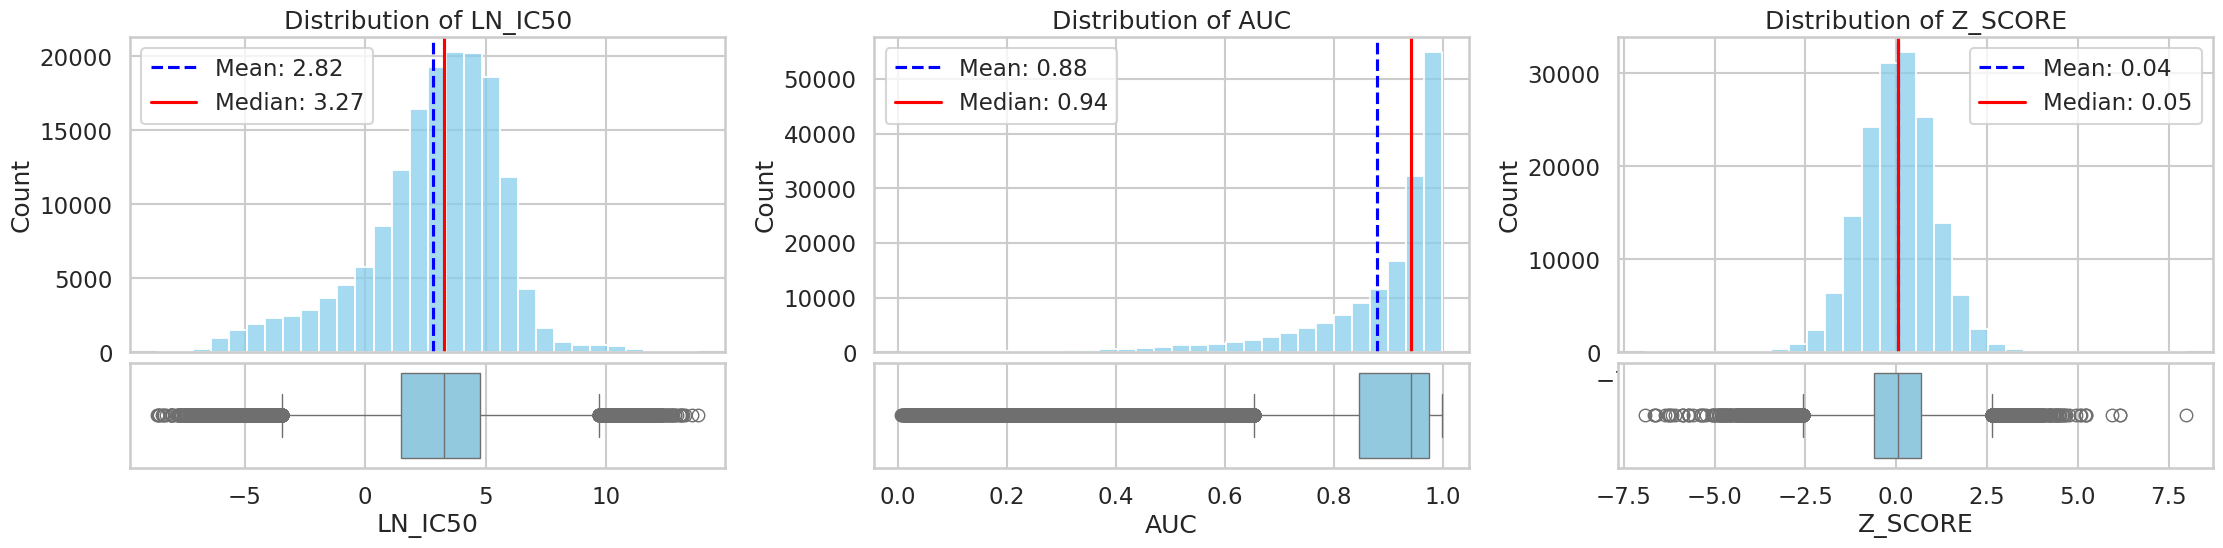

In [ ]:
continuous = gdsc.select_dtypes('float').columns
plot_distribution(data=gdsc, columns=continuous)

### Discrete / Categorical Variables

In [ ]:
identifiers = ["COSMIC_ID", "DRUG_ID", "DRUG_NAME", "CELL_LINE_NAME"] + ["TARGET"]
discretes = gdsc.select_dtypes(exclude='float').columns.difference(identifiers)

In [ ]:
def plot_proportions(data: pd.DataFrame = None, columns: list[str] = None, show_pct=True, n_cols=3):
    if data is None or columns is None:
        print("Missing Dataframe or columns")
        return

    n = len(columns)
    n_cols = min(n_cols, n)
    n_rows = math.ceil(n / n_cols)

    figure, axes = plt.subplots(ncols=n_cols, nrows=n_rows, figsize=(SCREEN_W, SCREEN_H * 1.5), constrained_layout=True)

    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    for i, column in enumerate(columns):
        value_counts = data[column].value_counts().sort_index()

        bars = axes[i].bar(
            value_counts.index.astype(str),
            value_counts.values,
            color="steelblue",
            edgecolor="black"
        )
        axes[i].set_title(column)
        axes[i].set_ylabel("Count")
        # axes[i].tick_params(axis="x", rotation=75)
        axes[i].set_xticks(range(len(value_counts)))
        axes[i].set_xticklabels(
            value_counts.index.astype(str),
            rotation=45,
            ha="right",
            fontsize=10
        )

        axes[i].set_ylim(0, value_counts.values.max() * 1.15)

        if show_pct:
            total = value_counts.sum()
            for bar, val in zip(bars, value_counts.values):
                pct = f"{(val / total) * 100:.1f}%"
                axes[i].text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    pct,
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    rotation=0,
                )
     # Hide unused subplots
    for i in range(len(columns), len(axes)):
        axes[i].set_visible(False)

    # remove plt.tight_layout() if using constrained_layout=True above, it's more robust
    plt.show()

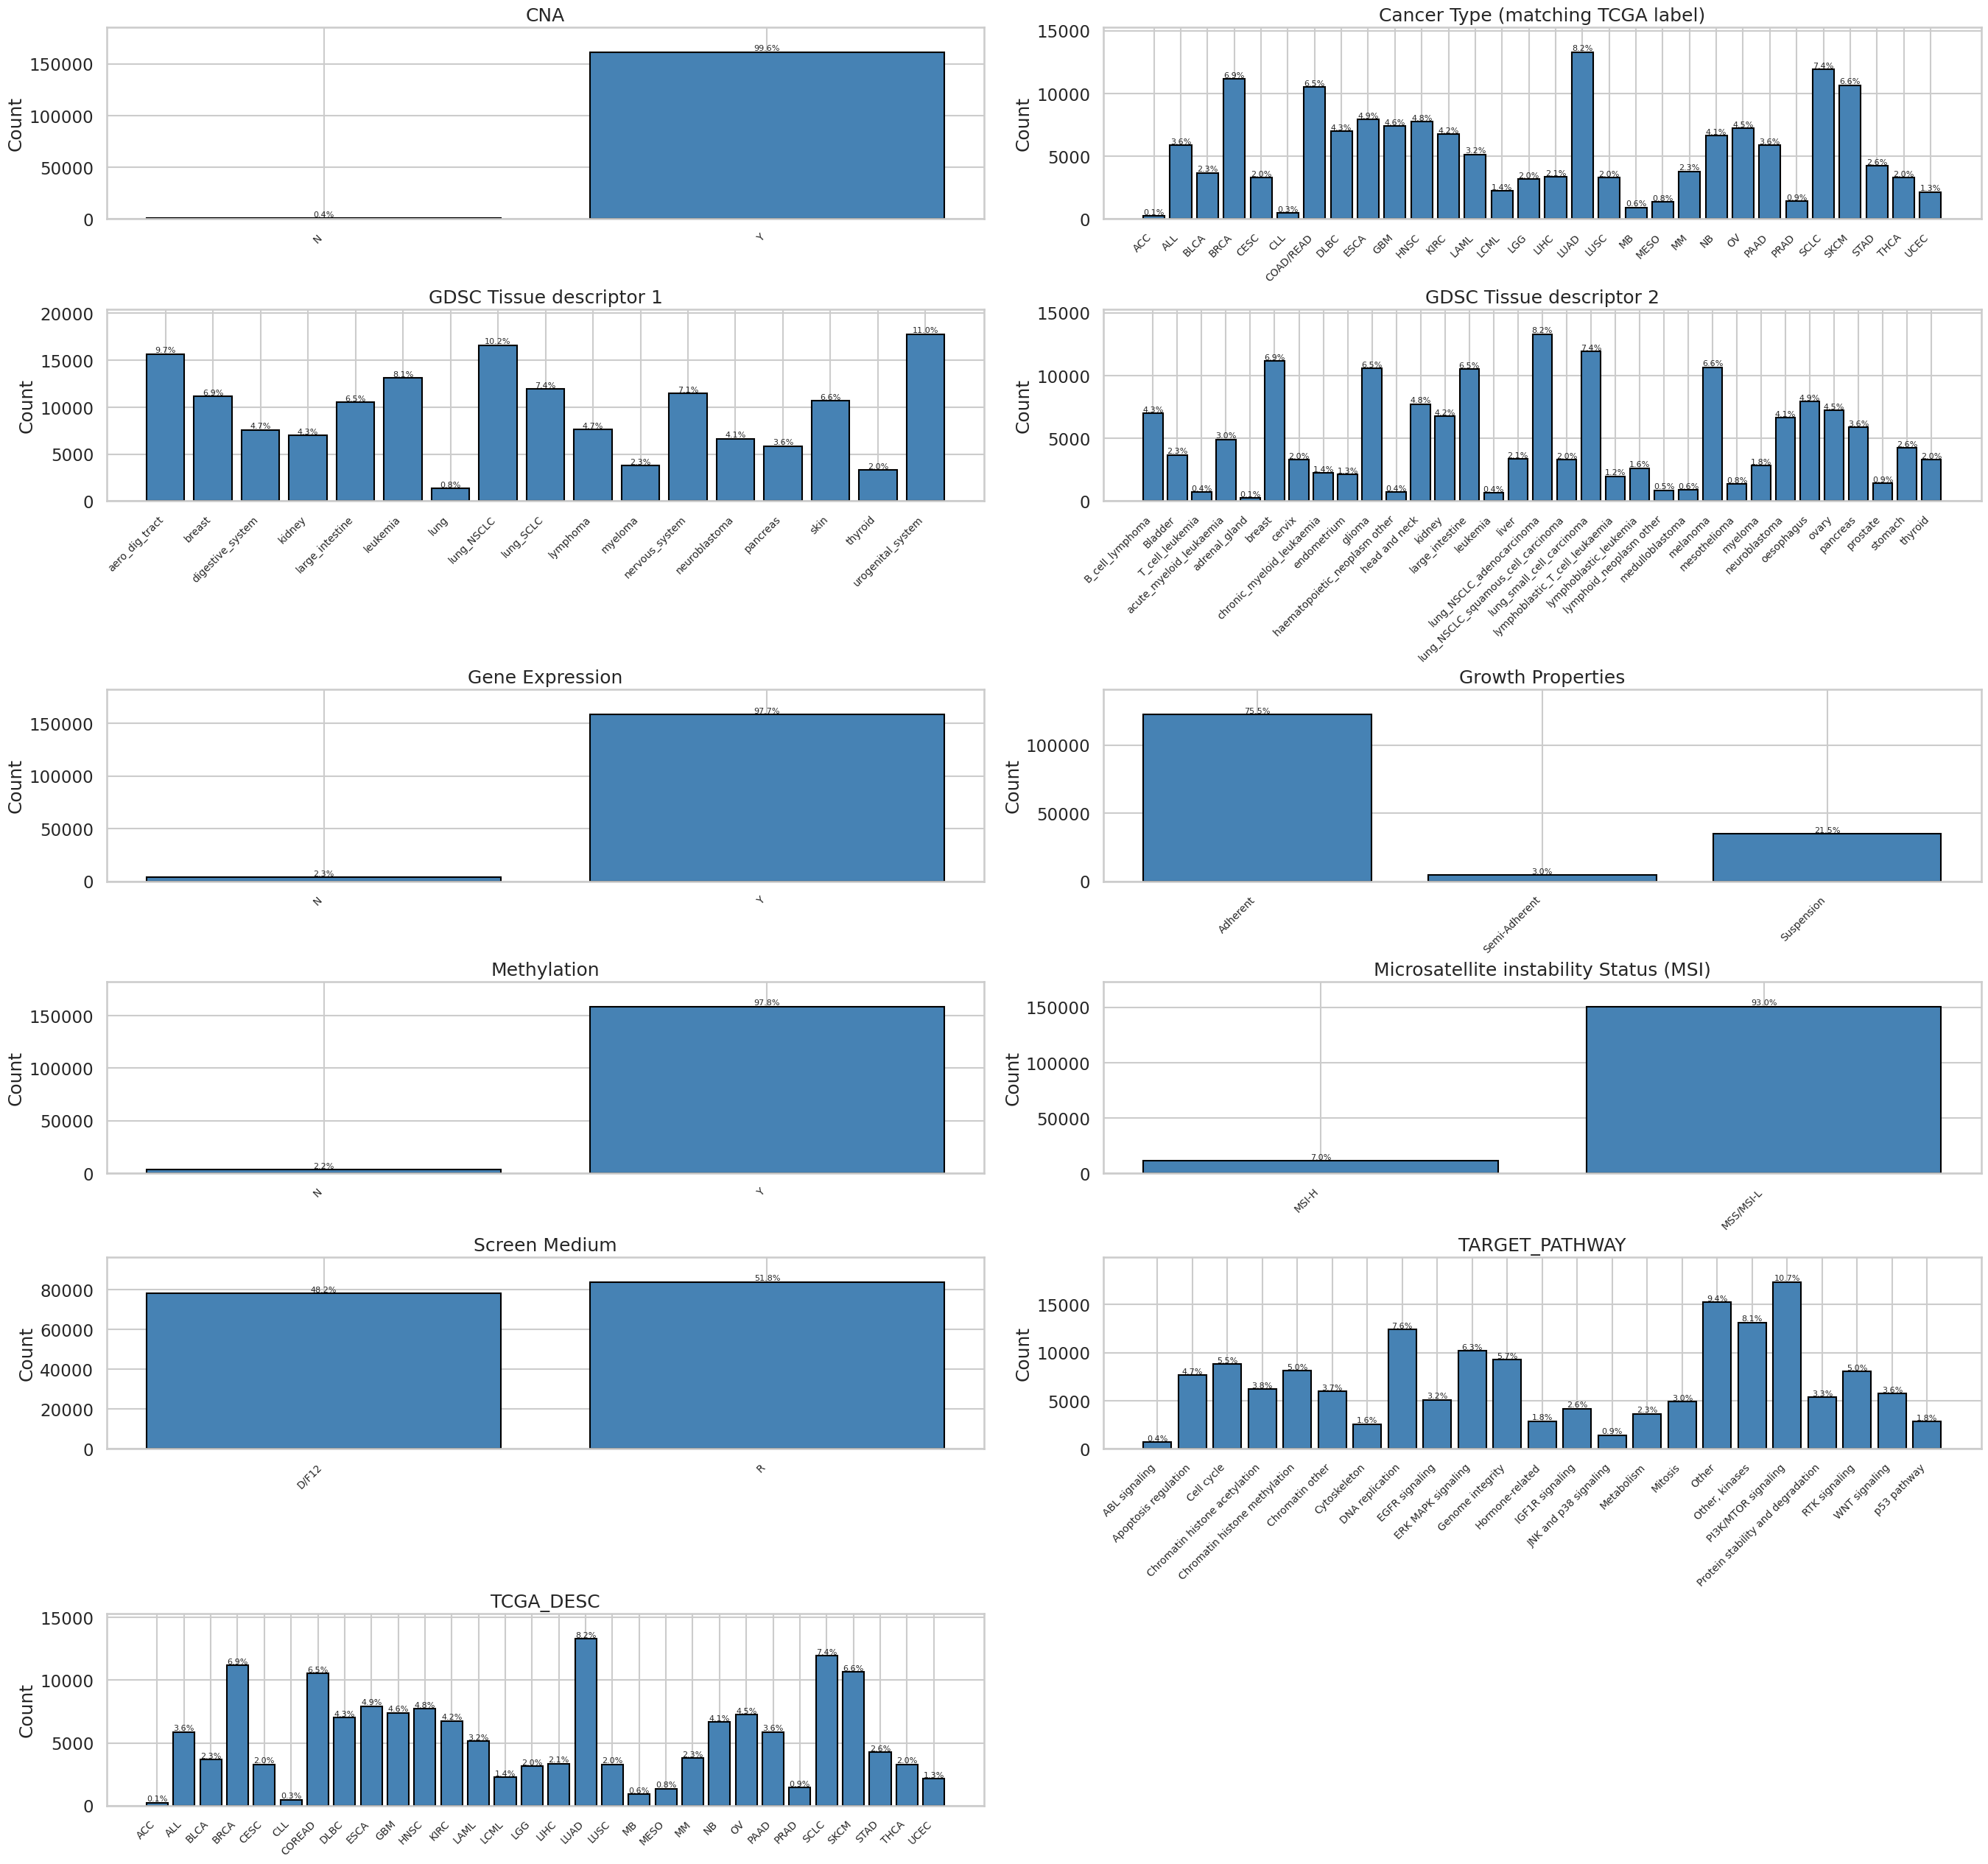

In [ ]:
plot_proportions(data=gdsc, columns=discretes, n_cols=2)

## Multivariate Analysis


### Continuous

In [ ]:
def plot_correlation(data: pd.DataFrame, columns: list, screen_w, screen_h, title="Correlation Matrix (Lower Triangle)"):
    """
    Plots correlation heatmap with the upper triangle masked.

    Parameters:
    - data: The dataframe containing the data.
    - columns: List of column names to include in the analysis.
    - screen_w, screen_h: Figure dimensions.
    """

    if data is None or columns is None:
        print("❌ Missing dataframe or columns")
        return

    # 1. Calculate Correlation
    corr_matrix = data[columns].corr()

    # 2. Create a Mask for the Upper Triangle
    # np.triu returns the upper triangle of an array.
    # The mask should be True for the values you want to HIDE.
    # mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    mask = None

    # 3. Setup Plot
    plt.figure(figsize=(screen_w, screen_h))
    plt.title(title)

    # 4. Render with Mask
    # Note: mask=mask argument hides the upper triangle
    sns.heatmap(corr_matrix, mask=mask, square=True, annot=True, cmap='coolwarm', center= 0, linewidths=0.5, fmt='.2f')

    plt.show()

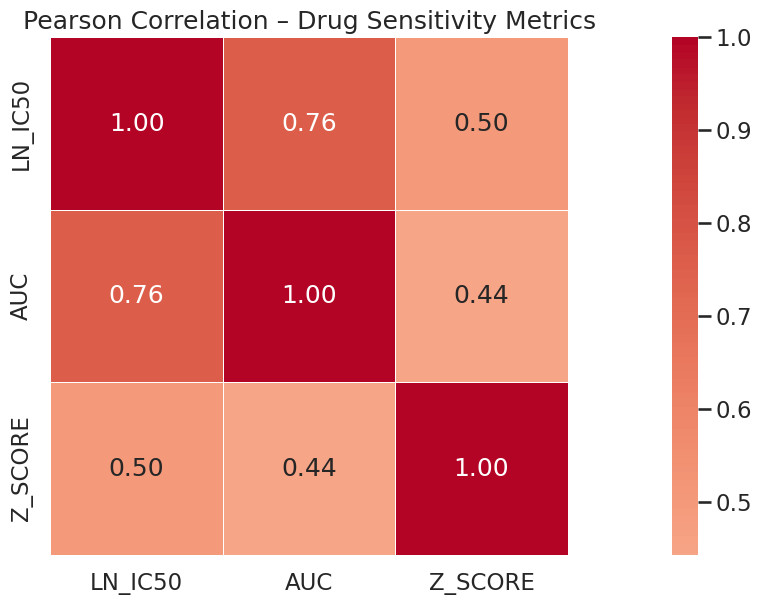

In [ ]:
plot_correlation(data=gdsc, columns=continuous, screen_h=SCREEN_H / 2.5, screen_w=SCREEN_W, title="Pearson Correlation – Drug Sensitivity Metrics")

### Discretes - Continuous

In [15]:
drug_stats = (
    gdsc.groupby("DRUG_NAME")[["LN_IC50", "AUC", "Z_SCORE"]]
    .agg(["median", "std", "count"])
    .round(3)
)

drug_stats.columns = ["_".join(c) for c in drug_stats.columns]
drug_stats = drug_stats.reset_index()
drug_stats

,DRUG_NAME,LN_IC50_median,LN_IC50_std,LN_IC50_count,AUC_median,AUC_std,AUC_count,Z_SCORE_median,Z_SCORE_std,Z_SCORE_count
0,5-Fluorouracil,4.462,1.703,737,0.928,0.080,737,0.044,0.992,737
1,5-azacytidine,2.893,1.368,574,0.848,0.085,574,-0.069,0.985,574
2,A-366,4.927,1.016,574,0.971,0.019,574,0.054,0.991,574
3,ABT737,2.278,2.069,726,0.854,0.187,726,0.195,1.008,726
4,AGI-5198,4.712,0.915,727,0.969,0.018,727,0.013,1.012,727
...,...,...,...,...,...,...,...,...,...,...
241,YK-4-279,2.123,1.668,727,0.813,0.116,727,-0.073,1.011,727
242,ZM447439,2.538,1.704,715,0.872,0.102,715,-0.023,1.000,715
243,alpha-lipoic acid,7.705,1.002,572,0.976,0.017,572,0.057,1.038,572
244,ascorbate (vitamin C),10.450,1.288,567,0.977,0.034,567,0.156,1.005,567


## Drug Sensitivity Patterns

### Most Effective Drugs
We rank all drugs by **median LN_IC50 across all cell lines** and display the 15 most potent. These are drugs that inhibit 50 % of cell growth at the lowest concentration — candidates of high pharmacological interest.

Error bars (±1 SD) are shown to distinguish drugs that are universally potent from those that are potent only in a subset of cell lines.


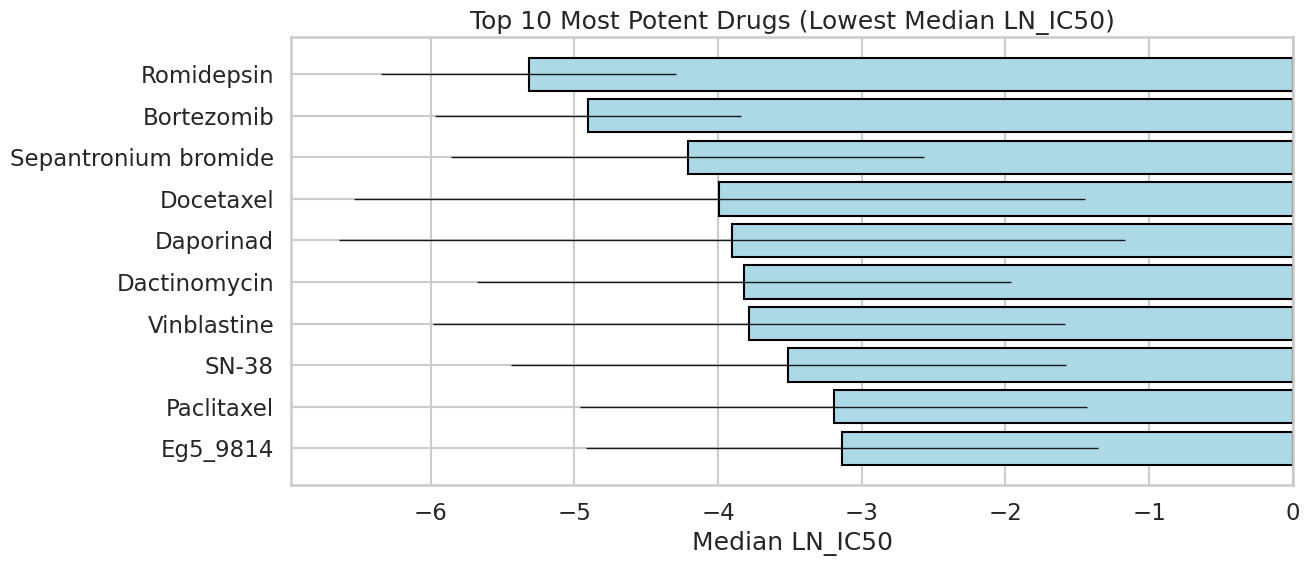

In [ ]:
top_effective = drug_stats.nsmallest(10, "LN_IC50_median")

fig, ax = plt.subplots(figsize=(SCREEN_W * .5, 6))
bars = ax.barh(top_effective["DRUG_NAME"], top_effective["LN_IC50_median"],
               xerr=top_effective["LN_IC50_std"], color="lightblue",
               error_kw={"elinewidth": 1}, edgecolor="black")
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Median LN_IC50")
ax.set_title("Top 10 Most Potent Drugs (Lowest Median LN_IC50)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

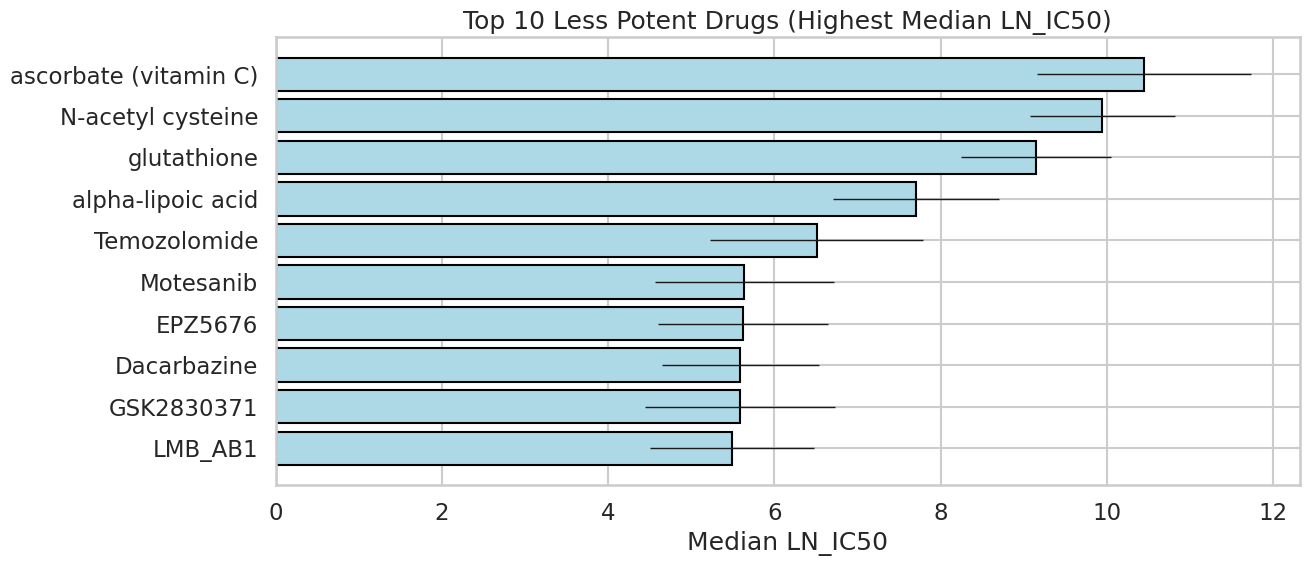

In [ ]:
top_effective = drug_stats.nlargest(10, "LN_IC50_median")

fig, ax = plt.subplots(figsize=(SCREEN_W * .5, 6))

bars = ax.barh(top_effective["DRUG_NAME"], top_effective["LN_IC50_median"],
               xerr=top_effective["LN_IC50_std"], color="lightblue",
               error_kw={"elinewidth": 1}, edgecolor="black")

ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Median LN_IC50")
ax.set_title("Top 10 Less Potent Drugs (Highest Median LN_IC50)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Drugs with Highly Variable Response Across Cell Lines

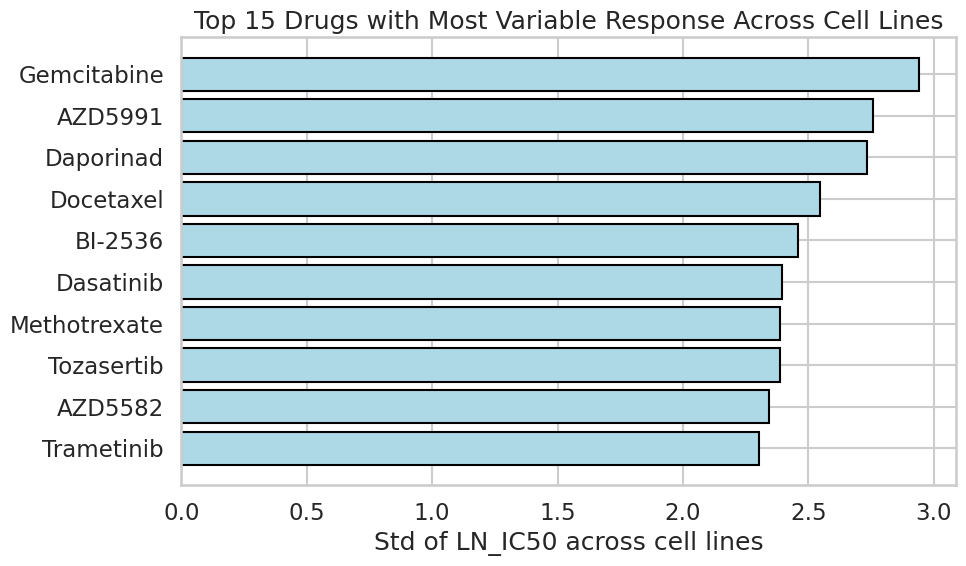

In [ ]:
top_variable = drug_stats.nlargest(10, "LN_IC50_std")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top_variable["DRUG_NAME"], top_variable["LN_IC50_std"],
        color="lightblue", edgecolor="black")

ax.set_xlabel("Std of LN_IC50 across cell lines")
ax.set_title("Top 15 Drugs with Most Variable Response Across Cell Lines")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Cancer Cell Line Analysis

### LN_IC50 Distribution by Cancer Type

A **box plot sorted by median LN_IC50** lets us rank cancer types from most drug-sensitive (left) to most drug-resistant (right) globally. The red dashed line marks the overall median across all rows, serving as a neutral reference point.

Note that this global view aggregates across all drugs — a cancer type that appears resistant overall may still harbour a narrow but targetable sensitivity to specific agents (explored in the heatmap and selective sensitivity analysis below).


/tmp/ipykernel_458947/2839885175.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gdsc, x="TCGA_DESC", y="LN_IC50", order=cancer_order,
/tmp/ipykernel_458947/2839885175.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)


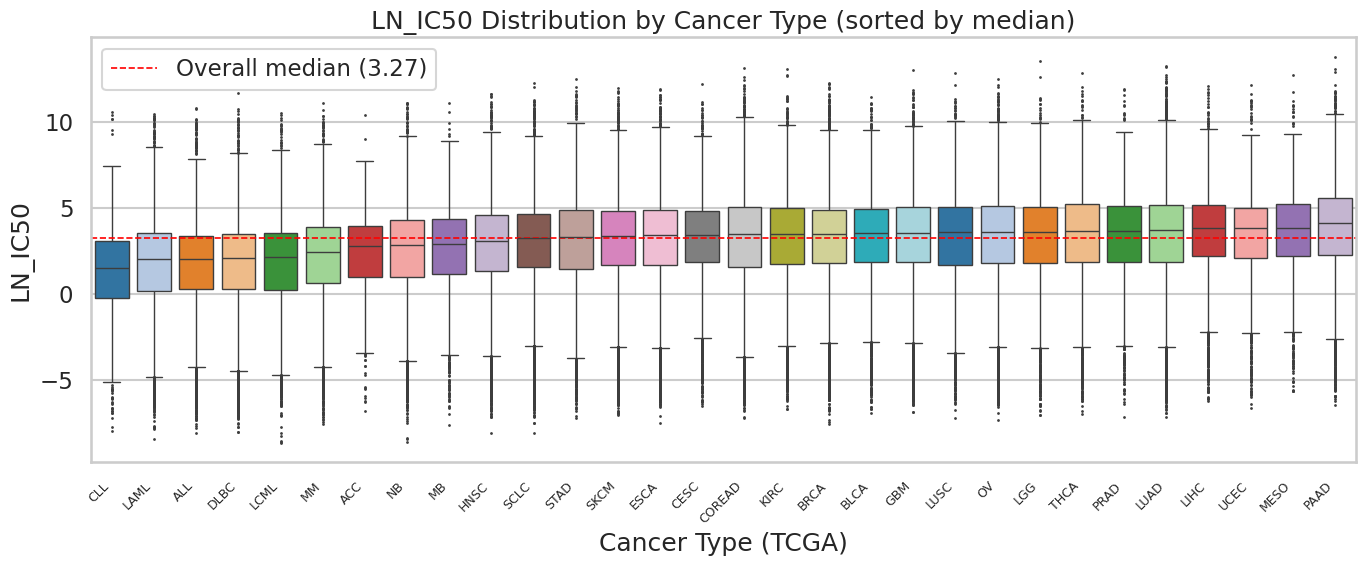

In [ ]:
cancer_order = (
    gdsc.groupby(["TCGA_DESC"])["LN_IC50"]
    .median()
    .sort_values()
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=gdsc, x="TCGA_DESC", y="LN_IC50", order=cancer_order,
            palette="tab20", fliersize=1, ax=ax)

ax.axhline(gdsc["LN_IC50"].median(), color="red", linestyle="--",
           linewidth=1.2, label=f"Overall median ({gdsc['LN_IC50'].median():.2f})")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_title("LN_IC50 Distribution by Cancer Type (sorted by median)")
ax.set_xlabel("Cancer Type (TCGA)")
ax.set_ylabel("LN_IC50")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# pivot = (
#     gdsc.groupby(["TCGA_DESC", "TARGET_PATHWAY"])["LN_IC50"]
#     .median()
#     .unstack("TARGET_PATHWAY")
# )

# fig, ax = plt.subplots(figsize=(16, 9))
# sns.heatmap(pivot, cmap="RdYlGn_r", center=pivot.stack().median(),
#             linewidths=0.3, ax=ax, cbar_kws={"label": "Median LN_IC50"})
# ax.set_title("Median LN_IC50 by Cancer Type and Target Pathway(Green = sensitive, Red = resistant)")
# ax.set_xlabel("Target Pathway")
# ax.set_ylabel("Cancer Type (TCGA)")
# plt.xticks(rotation=45, ha="right", fontsize=8)
# plt.tight_layout()
# plt.show()

## Genomic, Transcriptomic, and Epigenomic Influence on Drug Response

Influence of Mutations (CNA), Gene Expression, Methylation and Microsatellite instability Status (MSI) on drug sensitivity.

In [18]:
genomic_flags = ["CNA", "Gene Expression", "Methylation", "Microsatellite instability Status (MSI)"]
sensitivity_metrics = ["LN_IC50", "AUC", "Z_SCORE"]

In [19]:
for flag in genomic_flags:
    print(f"\n{flag}")
    print(gdsc.groupby(flag)[sensitivity_metrics].agg(["median", "std", "count"]).round(3))


CNA
    LN_IC50                   AUC                Z_SCORE               
     median    std   count median    std   count  median    std   count
CNA                                                                    
N     3.508  2.504     658  0.935  0.115     658   0.310  0.762     658
Y     3.270  2.837  161445  0.941  0.149  161445   0.048  1.000  161445

Gene Expression
                LN_IC50                   AUC                Z_SCORE         \
                 median    std   count median    std   count  median    std   
Gene Expression                                                               
N                 2.830  2.703    3761  0.926  0.167    3761  -0.248  1.023   
Y                 3.283  2.838  158342  0.942  0.148  158342   0.056  0.998   

                         
                  count  
Gene Expression          
N                  3761  
Y                158342  

Methylation
            LN_IC50                   AUC                Z_SCORE         \
    

/tmp/ipykernel_9171/2065529169.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gdsc, x=flag, y=metric, palette="Set2",
/tmp/ipykernel_9171/2065529169.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gdsc, x=flag, y=metric, palette="Set2",
/tmp/ipykernel_9171/2065529169.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gdsc, x=flag, y=metric, palette="Set2",
/tmp/ipykernel_9171/2065529169.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variab

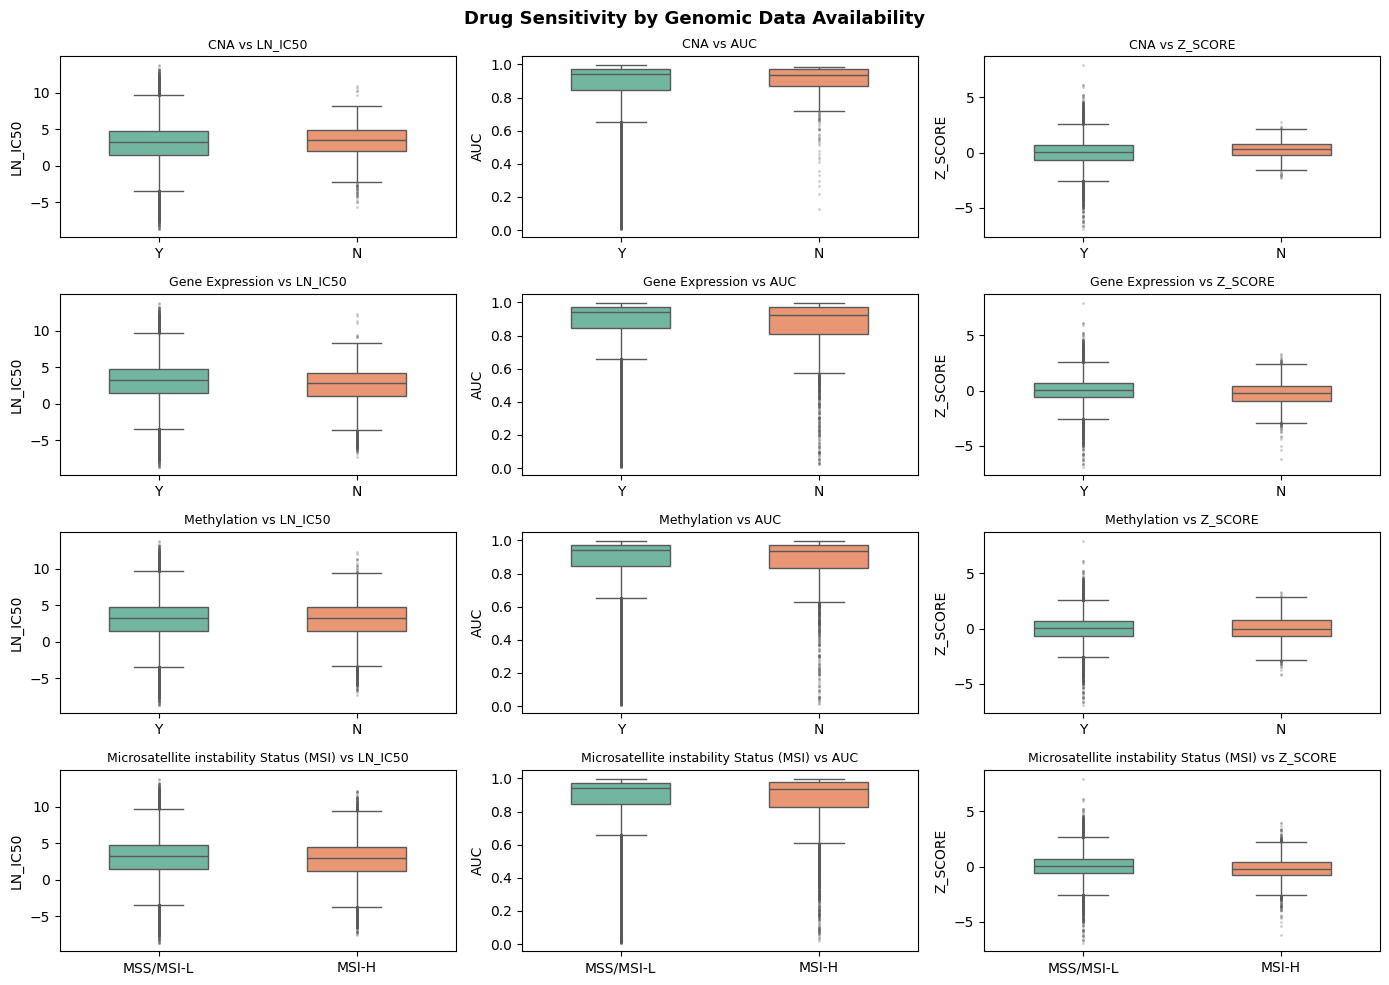

In [22]:
fig, axes = plt.subplots(len(genomic_flags), len(sensitivity_metrics), figsize=(14, 10))

for i, flag in enumerate(genomic_flags):
    for j, metric in enumerate(sensitivity_metrics):
        ax = axes[i][j]
        sns.boxplot(data=gdsc, x=flag, y=metric, palette="Set2",
                    width=0.5, flierprops=dict(marker=".", markersize=2, alpha=0.3), ax=ax)
        ax.set_title(f"{flag} vs {metric}", fontsize=9)
        ax.set_xlabel("")

plt.suptitle("Drug Sensitivity by Genomic Data Availability", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("genomic_flags_vs_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()